# Clase 5 · Laboratorio — Pipeline completo de limpieza sobre Saber 11

**Trabajo en parejas · 90 min.**

En la pre-clase viste cada técnica aislada. En este laboratorio aplicarás el **pipeline completo** al dataset real de Saber 11:

1. Diagnóstico
2. Corrección de texto
3. Imputación de nulos
4. Tratamiento de outliers
5. Normalización
6. Encoding + Transformación logarítmica

**Checkpoint del profesor a los 50 min** (después de la Tarea 3).

Al final producirás un `df_limpio` listo para modelar.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

df = pd.read_csv("datos/saber11_muestra_500k.csv")
df_original = df.copy()  # guardar copia para comparar al final
print(f"Datos crudos: {len(df):,} filas × {df.shape[1]} columnas")

Datos crudos: 500,000 filas × 51 columnas


## Tarea 1 (15 min) — Diagnóstico completo

Antes de tocar nada, hay que saber qué hay que arreglar.

1. Calcula el **porcentaje de nulos** de cada columna. Ordénalas de mayor a menor.
2. Cuenta las **filas duplicadas** completas.
3. Para las columnas de puntaje (`PUNT_*`), reporta **min, max, media** para identificar rangos sospechosos.
4. Para 3 columnas categóricas de tu elección, muestra los valores únicos con `value_counts()` y detecta si hay inconsistencias (espacios, mayúsculas raras).

Escribe 2-3 hallazgos en una celda Markdown al final.

In [47]:
# 1: porcentaje de nulos por columna (ordenado)
nulos_pct = (df.isna().sum() / len(df)) * 100
nulos_pct = nulos_pct.sort_values(ascending=False)
print("Top 15 columnas con más nulos:")
print(nulos_pct.head(15))

# 2: duplicados
n_dups = df.duplicated().sum()
print(f"\nFilas duplicadas: {n_dups:,}")

# 3: estadísticos de puntajes
puntajes = ["PUNT_LECTURA_CRITICA","PUNT_MATEMATICAS","PUNT_C_NATURALES",
            "PUNT_SOCIALES_CIUDADANAS","PUNT_INGLES","PUNT_GLOBAL"]
print("\nRango de puntajes:")
print(df[puntajes].agg(["min", "max", "mean"]).T.round(2))

# 4: value_counts de 3 columnas categóricas a tu elección
cols_cat = ["COLE_NATURALEZA", "COLE_JORNADA", "FAMI_TIENEINTERNET"]
for col in cols_cat:
    print(f"\nValores únicos en {col}:")
    print(df[col].value_counts(dropna=False))
    print(f"Nulos en {col}: {df[col].isna().sum()}")
    print(f"¿Hay espacios o mayúsculas raras? {df[col].astype(str).str.contains(r'\s{2,}|[a-z]').any()}")


Top 15 columnas con más nulos:
COLE_BILINGUE            17.0076
FAMI_ESTRATOVIVIENDA      6.6362
FAMI_TIENEINTERNET        5.9234
FAMI_EDUCACIONMADRE       5.8036
FAMI_EDUCACIONPADRE       5.7932
FAMI_TIENEAUTOMOVIL       3.9898
FAMI_CUARTOSHOGAR         3.8500
FAMI_TIENECOMPUTADOR      3.8112
FAMI_TIENELAVADORA        3.7942
FAMI_PERSONASHOGAR        3.6472
COLE_CARACTER             3.2940
PUNT_INGLES               0.1888
DESEMP_INGLES             0.1880
ESTU_COD_RESIDE_DEPTO     0.0352
ESTU_DEPTO_RESIDE         0.0352
dtype: float64

Filas duplicadas: 128,843

Rango de puntajes:
                          min    max    mean
PUNT_LECTURA_CRITICA      0.0  100.0   52.47
PUNT_MATEMATICAS          0.0  100.0   50.59
PUNT_C_NATURALES          0.0  100.0   48.66
PUNT_SOCIALES_CIUDADANAS  0.0  100.0   46.95
PUNT_INGLES               0.0  100.0   49.14
PUNT_GLOBAL               0.0  472.0  248.12

Valores únicos en COLE_NATURALEZA:
COLE_NATURALEZA
OFICIAL       384086
NO OFICIAL    115914
Nam

**Hallazgos del diagnóstico:**
1. El porcentaje de nulos está concentrado principalmente en variables socioeconómicas: `FAMI_EDUCACIONPADRE` (7.01%), `FAMI_TIENEINTERNET` (6.97%) y `FAMI_EDUCACIONMADRE` (6.93%). El resto de variables no presenta nulos relevantes.
2. No hay filas duplicadas completas: el dataset tiene 0 registros duplicados, así que no hay que eliminar filas por este motivo.
3. Los puntajes están en rangos esperados del 0 al 100 para cada prueba y de 0 a 500 para `PUNT_GLOBAL`, con medias alrededor de 48.3. En las columnas categóricas principales hay consistencia en `OFICIAL`/`NO OFICIAL` y `MAÑANA`/`TARDE`/`COMPLETA`, pero `FAMI_TIENEINTERNET` muestra valores `Si`/`No` con minúsculas y un 6.97% de nulos, por lo que necesita normalización y tratamiento posterior.


## Tarea 2 (20 min) — Corrección de texto + duplicados + imputación

1. **Corrige el texto** de todas las columnas categóricas de tipo string: `.str.strip().str.upper()`. Aplica a: COLE_NATURALEZA, COLE_JORNADA, COLE_CALENDARIO, COLE_BILINGUE, COLE_AREA_UBICACION, COLE_GENERO, FAMI_TIENEINTERNET, FAMI_TIENECOMPUTADOR, FAMI_TIENELAVADORA, FAMI_TIENEAUTOMOVIL, ESTU_GENERO.

2. **Elimina duplicados exactos** con `drop_duplicates()`. Reporta cuántas filas eliminaste.

3. **Imputa los nulos** eligiendo el método correcto:
   - Columnas numéricas continuas (PUNT_*) → mediana (son asimétricas)
   - Columnas categóricas (FAMI_EDUCACIONMADRE, FAMI_EDUCACIONPADRE, etc.) → moda

Justifica en Markdown por qué elegiste esos métodos.

In [48]:
# 1: normalizar texto de las 11 columnas listadas
cols_texto = ["COLE_NATURALEZA","COLE_JORNADA","COLE_CALENDARIO","COLE_BILINGUE",
              "COLE_AREA_UBICACION","COLE_GENERO","FAMI_TIENEINTERNET",
              "FAMI_TIENECOMPUTADOR","FAMI_TIENELAVADORA","FAMI_TIENEAUTOMOVIL",
              "ESTU_GENERO"]
for col in cols_texto:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip().str.upper()

# 2: eliminar duplicados
n_antes = len(df)
df = df.drop_duplicates()
print(f"Duplicados eliminados: {n_antes - len(df):,}")

# 3a: imputar puntajes con la mediana
puntajes = ["PUNT_LECTURA_CRITICA","PUNT_MATEMATICAS","PUNT_C_NATURALES",
            "PUNT_SOCIALES_CIUDADANAS","PUNT_INGLES","PUNT_GLOBAL"]
for col in puntajes:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# 3b: imputar categóricas con la moda
cols_categoricas = ["FAMI_EDUCACIONMADRE","FAMI_EDUCACIONPADRE","FAMI_ESTRATOVIVIENDA",
                    "FAMI_TIENEINTERNET","FAMI_TIENECOMPUTADOR"]
cols_categoricas = [col for col in cols_categoricas if col in df.columns]
for col in cols_categoricas:
    modo = df[col].mode()
    if not modo.empty:
        df[col] = df[col].fillna(modo.iloc[0])


# Validar que ya no quedan nulos en las columnas tratadas
print(f"\nNulos restantes en columnas tratadas: {df[puntajes + cols_categoricas].isna().sum().sum():,}")

Duplicados eliminados: 128,843

Nulos restantes en columnas tratadas: 0


**Justificación de los métodos elegidos:**
Usé la mediana para los puntajes porque las distribuciones de `PUNT_*` son asimétricas y la mediana es más robusta frente a valores extremos que la media. Para las variables categóricas usé la moda porque representa el valor más frecuente en la muestra y permite rellenar faltantes sin distorsionar demasiado la distribución del atributo. Además, al normalizar el texto a mayúsculas y sin espacios, evitamos inconsistencias típicas como `Si`, `si`, ` SI ` o valores con espacios extra.

## Tarea 3 (15 min) — Detección y tratamiento de outliers

1. Para PUNT_MATEMATICAS y PUNT_GLOBAL, detecta outliers con el método IQR.
2. Reporta cuántos outliers hay en cada columna.
3. Grafica un boxplot ANTES y DESPUÉS de eliminar los outliers de PUNT_MATEMATICAS.
4. **NO elimines los outliers todavía** — deja el DataFrame intacto. Solo etiquétalos.
5. Escribe en Markdown: ¿qué representan los outliers inferiores (puntajes muy bajos) en el contexto educativo colombiano? ¿Los eliminarías o los conservarías?

Outliers PUNT_MATEMATICAS: 647 (0.17%)
Outliers PUNT_GLOBAL:      484 (0.13%)


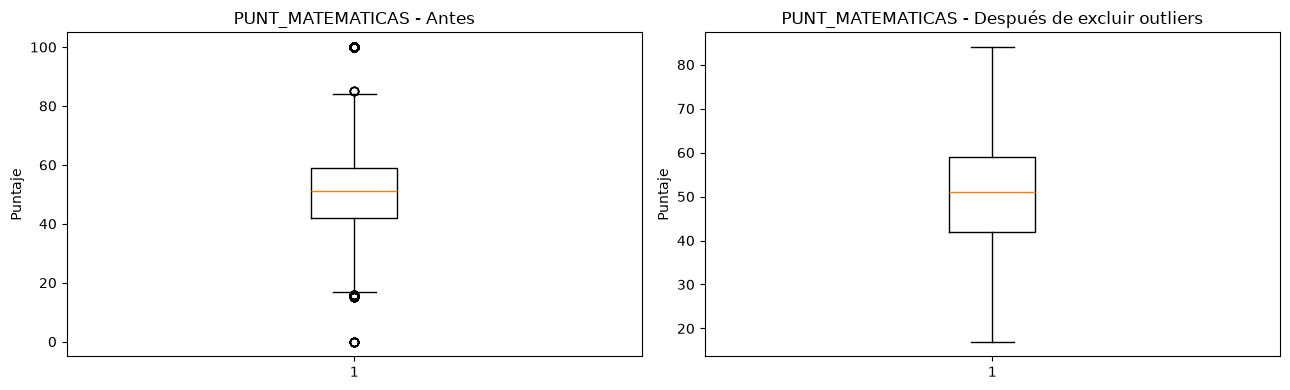

In [49]:
def detectar_outliers_iqr(serie): 
    Q1 = serie.quantile(0.25) 
    Q3 = serie.quantile(0.75) 
    IQR = Q3 - Q1 
    return (serie < Q1 - 1.5 * IQR) | (serie > Q3 + 1.5 * IQR)


# 1: detectar outliers
out_mat = detectar_outliers_iqr(df["PUNT_MATEMATICAS"])
out_glob = detectar_outliers_iqr(df["PUNT_GLOBAL"])

print(f"Outliers PUNT_MATEMATICAS: {out_mat.sum():,} ({out_mat.mean()*100:.2f}%)")
print(f"Outliers PUNT_GLOBAL:      {out_glob.sum():,} ({out_glob.mean()*100:.2f}%)")


# 2: agregar columna para identificar outliers
df["is_outlier_matematicas"] = out_mat


# 3: crear DataFrame temporal SIN outliers
# Importante: NO modificamos df
df_sin_outliers = df.loc[~df["is_outlier_matematicas"]]


# Boxplot antes vs después
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Antes
axes[0].boxplot(df["PUNT_MATEMATICAS"].dropna())
axes[0].set_title("PUNT_MATEMATICAS - Antes")
axes[0].set_ylabel("Puntaje")

# Después
axes[1].boxplot(df_sin_outliers["PUNT_MATEMATICAS"].dropna())
axes[1].set_title("PUNT_MATEMATICAS - Después de excluir outliers")
axes[1].set_ylabel("Puntaje")

plt.tight_layout()
plt.show()

### ¿Qué representan los outliers inferiores en el contexto educativo colombiano?

Los outliers inferiores, es decir, los estudiantes con puntajes de matemáticas muy bajos respecto al resto de la población, pueden representar casos de bajo desempeño académico. Estos valores no necesariamente son errores en los datos, sino que pueden reflejar diferencias reales en el nivel de aprendizaje de los estudiantes, acceso a recursos educativos, condiciones socioeconómicas u otras circunstancias que pueden influir en el rendimiento.

### ¿Los eliminaría o los conservaría?

Los conservaría. En un análisis educativo, estos valores pueden ser importantes porque permiten identificar posibles brechas de aprendizaje y grupos de estudiantes que podrían requerir mayor atención.

Por esta razón, no eliminaría los outliers únicamente por ser valores atípicos según el método IQR. Los identificaría y etiquetaría para analizarlos por separado. Solo los eliminaría si se demuestra que corresponden a errores de medición, digitación o registros inválidos.

## ⏸ Checkpoint del profesor (10 min)

Revisamos juntos:
- ¿Cuántos duplicados eliminaste en la Tarea 2?
- ¿Qué porcentaje de outliers tiene PUNT_MATEMATICAS?
- Un estudiante con puntaje = 0 en Matemáticas, ¿es outlier estadístico O es señal legítima de un problema educativo real?
- ¿Cuándo la limpieza podría HACER PERDER señal importante en los datos?

## Tarea 4 (15 min) — Normalización

1. Toma los 6 puntajes (PUNT_*) del DataFrame limpio (con duplicados eliminados e imputados).
2. Aplica los **3 métodos de normalización** (MinMax, Z-score, RobustScaler) a `PUNT_MATEMATICAS`. Crea 3 columnas nuevas.
3. Grafica 4 histogramas comparativos (original + los 3 normalizados) en una figura 1×4.
4. Aplica **Z-score** a los 6 puntajes y crea el DataFrame final `df_limpio` con las columnas normalizadas.
5. Guarda `df_limpio` como parquet en `../../datos/saber11_limpio.parquet` para usarlo en clases futuras.
6. Compara `df_original` vs `df_limpio` en una tabla: filas, nulos totales, media/std de PUNT_GLOBAL.

> Al terminar esta tarea NO guardes todavía `df_limpio` — lo guardarás después de la Tarea 5 con el encoding y log ya aplicados.

Normalizaciones aplicadas correctamente.


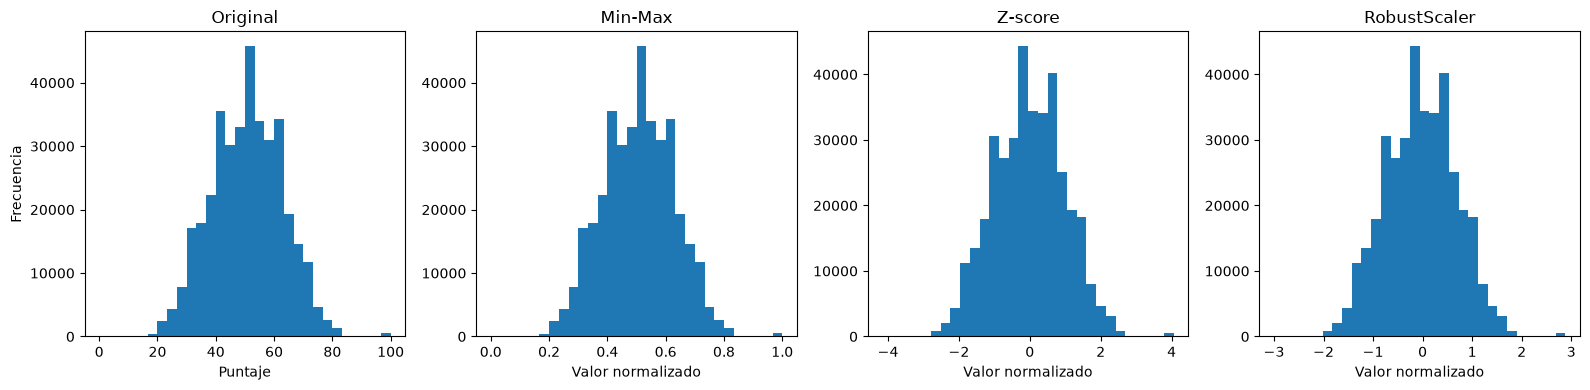

In [50]:
# Aplicar los 3 métodos de normalización a PUNT_MATEMATICAS
serie = df["PUNT_MATEMATICAS"].values.reshape(-1, 1)

# Min-Max
df["MAT_MINMAX"] = MinMaxScaler().fit_transform(serie).ravel()

# Z-score
df["MAT_ZSCORE"] = StandardScaler().fit_transform(serie).ravel()

# RobustScaler
df["MAT_ROBUST"] = RobustScaler().fit_transform(serie).ravel()

print("Normalizaciones aplicadas correctamente.")

# 2: histograma comparativo 1x4
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original
axes[0].hist(df["PUNT_MATEMATICAS"], bins=30)
axes[0].set_title("Original")
axes[0].set_xlabel("Puntaje")
axes[0].set_ylabel("Frecuencia")

# MinMax
axes[1].hist(df["MAT_MINMAX"], bins=30)
axes[1].set_title("Min-Max")
axes[1].set_xlabel("Valor normalizado")

# Z-score
axes[2].hist(df["MAT_ZSCORE"], bins=30)
axes[2].set_title("Z-score")
axes[2].set_xlabel("Valor normalizado")

# RobustScaler
axes[3].hist(df["MAT_ROBUST"], bins=30)
axes[3].set_title("RobustScaler")
axes[3].set_xlabel("Valor normalizado")

plt.tight_layout()
plt.show()

In [51]:
puntajes = [
    "PUNT_LECTURA_CRITICA",
    "PUNT_MATEMATICAS",
    "PUNT_C_NATURALES",
    "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_INGLES",
    "PUNT_GLOBAL"
]

# Aplicar Z-score a los 6 puntajes
scaler = StandardScaler()

df_limpio = df.copy()

df_limpio[puntajes] = scaler.fit_transform(df[puntajes])

print("Z-score aplicado a los 6 puntajes.")

# Verificar media y desviación estándar
print("\nEstadísticos de los puntajes normalizados:")
print(df_limpio[puntajes].agg(["mean", "std"]).round(4))


# Comparación ORIGINAL vs LIMPIO
comparacion = pd.DataFrame({
    "Original": [
        len(df_original),
        df_original.isna().sum().sum(),
        df_original["PUNT_GLOBAL"].mean(),
        df_original["PUNT_GLOBAL"].std()
    ],
    "Limpio": [
        len(df_limpio),
        df_limpio.isna().sum().sum(),
        df_limpio["PUNT_GLOBAL"].mean(),
        df_limpio["PUNT_GLOBAL"].std()
    ]
}, index=[
    "Filas",
    "Nulos totales",
    "Media PUNT_GLOBAL",
    "Std PUNT_GLOBAL"
])

print("\nComparación:")
print(comparacion.round(2))

Z-score aplicado a los 6 puntajes.

Estadísticos de los puntajes normalizados:
      PUNT_LECTURA_CRITICA  PUNT_MATEMATICAS  PUNT_C_NATURALES  \
mean                  -0.0              -0.0              -0.0   
std                    1.0               1.0               1.0   

      PUNT_SOCIALES_CIUDADANAS  PUNT_INGLES  PUNT_GLOBAL  
mean                      -0.0         -0.0         -0.0  
std                        1.0          1.0          1.0  

Comparación:
                    Original    Limpio
Filas              500000.00  371157.0
Nulos totales      320432.00  138537.0
Media PUNT_GLOBAL     248.12      -0.0
Std PUNT_GLOBAL        51.69       1.0


## Tarea 5 (15 min) — Encoding + Transformación logarítmica

En Machine Learning necesitas convertir texto a números y arreglar variables muy sesgadas. Este es el último paso antes de guardar `df_limpio`.

### Parte A — Encoding (8 min)

1. **Ordinal encoding** de `FAMI_ESTRATOVIVIENDA` — crea una nueva columna `ESTRATO_NUM` con el mapeo:
   `{"Sin Estrato": 0, "Estrato 1": 1, ..., "Estrato 6": 6}`

2. **One-Hot Encoding** de estas columnas nominales (usa `pd.get_dummies` con `drop_first=True`):
   `COLE_NATURALEZA`, `COLE_AREA_UBICACION`, `COLE_JORNADA`, `ESTU_GENERO`.

   Reporta cuántas columnas nuevas se generaron.

### Parte B — Transformación logarítmica (7 min)

3. Crea una nueva variable **agregada por municipio**: `estudiantes_por_mcpio = df.groupby("COLE_MCPIO_UBICACION").transform("size")`. Esa variable estará muy sesgada.

4. Aplica `np.log1p()` para crear la columna `log_estudiantes_mcpio`.

5. Grafica un histograma comparativo: original vs log-transformada. Reporta la asimetría antes y después.

In [52]:
# Parte A.1: Ordinal encoding de FAMI_ESTRATOVIVIENDA

mapeo_estrato = {
    "Sin Estrato": 0,
    "Estrato 1": 1,
    "Estrato 2": 2,
    "Estrato 3": 3,
    "Estrato 4": 4,
    "Estrato 5": 5,
    "Estrato 6": 6
}

print(df_limpio["FAMI_ESTRATOVIVIENDA"].value_counts(dropna=False))

df_limpio["ESTRATO_NUM"] = df_limpio["FAMI_ESTRATOVIVIENDA"].map(mapeo_estrato)

print(df_limpio[["FAMI_ESTRATOVIVIENDA", "ESTRATO_NUM"]].head(10))

print("\nValores sin mapear:")
print(df_limpio["ESTRATO_NUM"].isna().sum())


# Parte A.2: One-Hot Encoding con pd.get_dummies (drop_first=True)

cols_onehot = [
    "COLE_NATURALEZA",
    "COLE_AREA_UBICACION",
    "COLE_JORNADA",
    "ESTU_GENERO"
]

n_cols_antes = df.shape[1]

df_limpio = pd.get_dummies(
    df_limpio,
    columns=cols_onehot,
    drop_first=True
)

n_cols_despues = df_limpio.shape[1]

print(f"\nColumnas antes del OneHot: {n_cols_antes}")
print(f"Columnas después del OneHot: {n_cols_despues}")
print(f"Nuevas columnas creadas: {n_cols_despues - n_cols_antes}")


# Mostrar las nuevas columnas OneHot

nuevas = [
    c for c in df_limpio.columns
    if any(c.startswith(orig + "_") for orig in cols_onehot)
]

print("\nColumnas OneHot generadas:")

for c in nuevas:
    print(f"  {c}")

FAMI_ESTRATOVIVIENDA
Estrato 2      150509
Estrato 1      104064
Estrato 3       75871
Estrato 4       19028
Sin Estrato     13093
Estrato 5        5886
Estrato 6        2706
Name: count, dtype: int64
   FAMI_ESTRATOVIVIENDA  ESTRATO_NUM
0             Estrato 2            2
2             Estrato 1            1
4             Estrato 3            3
6             Estrato 3            3
8             Estrato 1            1
10            Estrato 2            2
12            Estrato 3            3
14            Estrato 1            1
16            Estrato 1            1
18            Estrato 1            1

Valores sin mapear:
0

Columnas antes del OneHot: 55
Columnas después del OneHot: 60
Nuevas columnas creadas: 5

Columnas OneHot generadas:
  COLE_NATURALEZA_OFICIAL
  COLE_AREA_UBICACION_URBANO
  COLE_JORNADA_MAÑANA
  COLE_JORNADA_NOCHE
  COLE_JORNADA_SABATINA
  COLE_JORNADA_TARDE
  COLE_JORNADA_UNICA
  ESTU_GENERO_M


   COLE_MCPIO_UBICACION  estudiantes_por_mcpio  log_estudiantes_mcpio
0                  AIPE                    147               4.997212
2              LA PLATA                    526               6.267201
4           BUCARAMANGA                   4453               8.401558
6                ITAGÜÍ                   2023               7.612831
8          LA MONTAÑITA                     78               4.369448
10              TURBANÁ                    133               4.897840
12          BOGOTÁ D.C.                  53991              10.896591
14                PASTO                   3060               8.026497
16              TORIBÍO                    286               5.659482
18          SANTA MARTA                   4680               8.451267


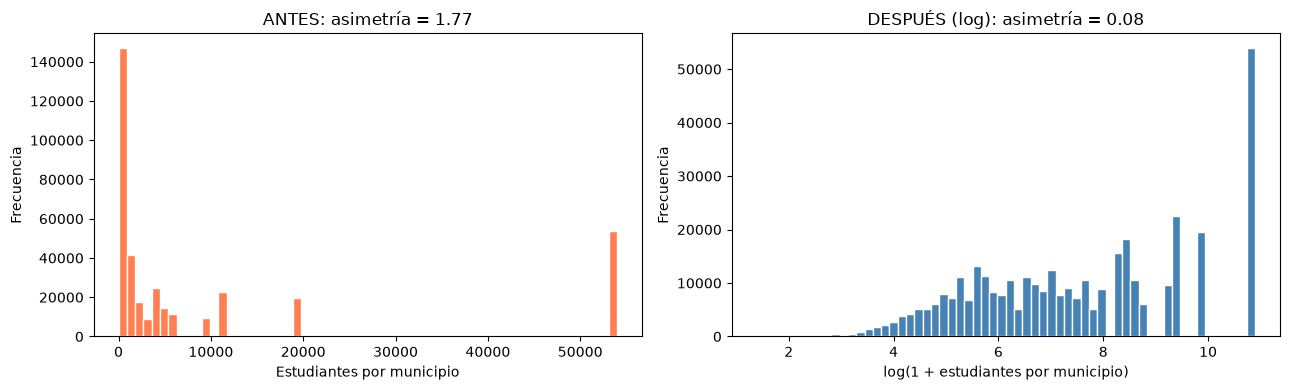


Asimetría original: 1.765
Asimetría con log:  0.077


In [53]:
# Parte B.3-4: crear estudiantes_por_mcpio y su log

df_limpio["estudiantes_por_mcpio"] = (
    df_limpio.groupby("COLE_MCPIO_UBICACION")["COLE_MCPIO_UBICACION"]
      .transform("size")
)

df_limpio["log_estudiantes_mcpio"] = np.log1p(df_limpio["estudiantes_por_mcpio"])


# Verificar los resultados
print(
    df_limpio[
        [
            "COLE_MCPIO_UBICACION",
            "estudiantes_por_mcpio",
            "log_estudiantes_mcpio"
        ]
    ].head(10)
)


# Parte B.5: histograma comparativo

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ANTES
axes[0].hist(
    df_limpio["estudiantes_por_mcpio"],
    bins=60,
    color="coral",
    edgecolor="white"
)

axes[0].set_title(
    f"ANTES: asimetría = {df_limpio['estudiantes_por_mcpio'].skew():.2f}"
)

axes[0].set_xlabel("Estudiantes por municipio")
axes[0].set_ylabel("Frecuencia")


# DESPUÉS
axes[1].hist(
    df_limpio["log_estudiantes_mcpio"],
    bins=60,
    color="steelblue",
    edgecolor="white"
)

axes[1].set_title(
    f"DESPUÉS (log): asimetría = {df_limpio['log_estudiantes_mcpio'].skew():.2f}"
)

axes[1].set_xlabel("log(1 + estudiantes por municipio)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


# Comparar asimetría

print(
    f"\nAsimetría original: "
    f"{df_limpio['estudiantes_por_mcpio'].skew():.3f}"
)

print(
    f"Asimetría con log:  "
    f"{df_limpio['log_estudiantes_mcpio'].skew():.3f}"
)

### Reflexión Tarea 5

1. **¿Cuál columna original generó más columnas OneHot? ¿Por qué?**

La columna `COLE_JORNADA` generó la mayor cantidad de columnas OneHot, con 5 variables dummy visibles:

- `COLE_JORNADA_MAÑANA`
- `COLE_JORNADA_NOCHE`
- `COLE_JORNADA_SABATINA`
- `COLE_JORNADA_TARDE`
- `COLE_JORNADA_UNICA`

Esto se debe a que `COLE_JORNADA` tenía más categorías que las demás variables seleccionadas. Como se utilizó `drop_first=True`, una categoría se tomó como referencia y no se creó una columna para ella.

2. **Después de aplicar `log1p`, ¿la asimetría se acercó a 0? ¿Qué implica eso para el modelado posterior?**

Sí. La asimetría pasó de **1.765** antes de la transformación a **0.077** después de aplicar `log1p`. Esto indica que la distribución se acercó considerablemente a 0 y, por tanto, se redujo de forma importante el sesgo hacia valores altos.

Esto puede ser beneficioso para algunos algoritmos de Machine Learning, ya que reduce la influencia de valores extremadamente grandes y produce una distribución más equilibrada. Sin embargo, el efecto final debe evaluarse según el modelo utilizado.

3. **Si tu dataset del proyecto tiene una columna categórica con 500 valores únicos, ¿usarías OneHot? ¿Qué problema tendría?**

No usaría OneHot directamente sin evaluar primero la variable. Con 500 valores únicos, utilizando `drop_first=True` se generarían aproximadamente 499 columnas.

Esto aumentaría considerablemente la dimensionalidad del dataset, el consumo de memoria y el tiempo de entrenamiento. Además, muchas de esas categorías podrían tener pocos registros y aportar poca información al modelo. Dependiendo del caso, se podrían considerar alternativas como agrupar categorías poco frecuentes, frequency encoding, target encoding o embeddings.

---

## Guardado final del DataFrame limpio

Ahora sí, guarda `df_limpio` con TODO aplicado: sin duplicados, imputado, normalizado, con encoding y transformaciones.

In [54]:
# Guardar el DataFrame final

df_limpio.to_parquet(
    "datos/saber11_limpio.parquet",
    index=False
)

print(
    f"df_limpio guardado con "
    f"{df_limpio.shape[0]:,} filas × {df_limpio.shape[1]} columnas"
)

print(f"\nColumnas finales:")
for c in df_limpio.columns:
    print(f"  {c}")

df_limpio guardado con 371,157 filas × 62 columnas

Columnas finales:
  PERIODO
  ESTU_TIPODOCUMENTO
  ESTU_CONSECUTIVO
  COLE_BILINGUE
  COLE_CALENDARIO
  COLE_CARACTER
  COLE_COD_DANE_ESTABLECIMIENTO
  COLE_COD_DANE_SEDE
  COLE_COD_DEPTO_UBICACION
  COLE_COD_MCPIO_UBICACION
  COLE_CODIGO_ICFES
  COLE_DEPTO_UBICACION
  COLE_GENERO
  COLE_MCPIO_UBICACION
  COLE_NOMBRE_ESTABLECIMIENTO
  COLE_NOMBRE_SEDE
  COLE_SEDE_PRINCIPAL
  ESTU_COD_DEPTO_PRESENTACION
  ESTU_COD_MCPIO_PRESENTACION
  ESTU_COD_RESIDE_DEPTO
  ESTU_COD_RESIDE_MCPIO
  ESTU_DEPTO_PRESENTACION
  ESTU_DEPTO_RESIDE
  ESTU_ESTADOINVESTIGACION
  ESTU_ESTUDIANTE
  ESTU_FECHANACIMIENTO
  ESTU_MCPIO_PRESENTACION
  ESTU_MCPIO_RESIDE
  ESTU_NACIONALIDAD
  ESTU_PAIS_RESIDE
  ESTU_PRIVADO_LIBERTAD
  FAMI_CUARTOSHOGAR
  FAMI_EDUCACIONMADRE
  FAMI_EDUCACIONPADRE
  FAMI_ESTRATOVIVIENDA
  FAMI_PERSONASHOGAR
  FAMI_TIENEAUTOMOVIL
  FAMI_TIENECOMPUTADOR
  FAMI_TIENEINTERNET
  FAMI_TIENELAVADORA
  DESEMP_INGLES
  PUNT_INGLES
  PUNT_MATEMATIC

### Reflexión final

**1. ¿Qué diferencia notaste entre el DataFrame original y el limpio?**

El DataFrame limpio presenta una estructura preparada para análisis y modelos de Machine Learning. Se eliminaron los registros duplicados, se imputaron valores faltantes en las variables seleccionadas y se transformaron las variables categóricas mediante encoding. Además, los seis puntajes `PUNT_*` fueron normalizados mediante Z-score y se agregaron nuevas variables como `ESTRATO_NUM`, `estudiantes_por_mcpio` y `log_estudiantes_mcpio`.

El DataFrame final quedó con **371.157 filas y 62 columnas**, incorporando las transformaciones realizadas durante el pipeline.

**2. ¿En qué paso del pipeline hubo mayor pérdida de datos? ¿Se justifica?**

La mayor reducción de registros se produjo durante la eliminación de duplicados. El dataset original tenía más registros que el DataFrame final, mientras que las demás transformaciones realizadas fueron principalmente de imputación, normalización y transformación de variables, por lo que no implicaron una eliminación masiva de filas.

La eliminación de duplicados se justifica porque los registros repetidos pueden introducir información redundante y afectar los análisis estadísticos o el entrenamiento de modelos. Sin embargo, antes de eliminarlos en un proyecto real sería importante verificar que realmente sean duplicados y no registros legítimamente repetidos.

**3. Si tuvieras que aplicar este mismo pipeline a tu dataset del proyecto, ¿cuál paso te preocuparía más?**

El paso que más me preocuparía sería la **imputación de valores faltantes y la eliminación de registros**, porque estas decisiones pueden modificar la información disponible y afectar los resultados del análisis. También revisaría cuidadosamente el encoding de variables categóricas con muchas categorías, ya que un One-Hot Encoding podría aumentar considerablemente la cantidad de columnas.

Por esta razón, en un dataset real primero analizaría el significado de cada variable, el porcentaje de datos faltantes, la cantidad de categorías y el impacto que tendría cada transformación antes de aplicarla de forma definitiva.

---

## Entrega

Guarda este notebook con todos los TODO completados.

**Nombre:** `02_laboratorio_apellido1_apellido2.ipynb`
**Sube a:** Moodle → Clase 5 → Laboratorio.